# Painel de Análise de Vendas


## Etapa 1 - Preparação e Importação de Dados

In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

 Carregar o vendas.csv



In [3]:
np.random.seed(42)
n = 400

lojas = {
    "Loja BH": "Sudeste",
    "Loja São Paulo": "Sudeste",
    "Loja Curitiba": "Sul",
    "Loja Salvador": "Nordeste",
    "Loja Brasília": "Centro-Oeste",
}

produtos = {
    "Notebook": ("Eletrônicos", 3500),
    "Monitor": ("Eletrônicos", 900),
    "Webcam": ("Eletrônicos", 250),
    "Mouse": ("Acessórios", 80),
    "Teclado": ("Acessórios", 150),
    "Headset": ("Acessórios", 220),
    "Cadeira": ("Móveis", 1200),
    "Mesa": ("Móveis", 700),
}

nomes_lojas = np.random.choice(list(lojas.keys()), n)
nomes_prod = np.random.choice(list(produtos.keys()), n)

dados = pd.DataFrame({
    "data": pd.to_datetime("2025-01-01") + pd.to_timedelta(np.random.randint(0, 365, n), unit="D"),
    "loja": nomes_lojas,
    "produto": nomes_prod,
    "quantidade": np.random.randint(1, 11, n).astype(float),
    "preco_unitario": [round(produtos[p][1] * np.random.uniform(0.9, 1.1), 2) for p in nomes_prod],
})
dados["categoria"] = dados["produto"].map(lambda p: produtos[p][0])
dados["regiao"] = dados["loja"].map(lojas)

dados.loc[np.random.choice(n, 12, replace=False), "preco_unitario"] = np.nan
dados.loc[np.random.choice(n, 10, replace=False), "quantidade"] = np.nan

dados.to_csv("vendas.csv", index=False)

In [4]:
path = "vendas.csv"

In [5]:
vendas_bruto = pd.read_csv(path)

In [6]:
vendas = vendas_bruto.copy()
vendas["data"] = pd.to_datetime(vendas["data"])

In [7]:
vendas.head()

,data,loja,produto,quantidade,preco_unitario,categoria,regiao
0,2025-07-16,Loja Salvador,Mesa,4.0,742.11,Móveis,Nordeste
1,2025-12-17,Loja Brasília,Webcam,4.0,256.49,Eletrônicos,Centro-Oeste
2,2025-05-13,Loja Curitiba,Teclado,5.0,141.49,Acessórios,Sul
3,2025-12-24,Loja Brasília,Headset,8.0,220.80,Acessórios,Centro-Oeste
4,2025-09-16,Loja Brasília,Notebook,5.0,3568.09,Eletrônicos,Centro-Oeste


 Criar a coluna faturamento

In [8]:
vendas["faturamento"] = vendas["quantidade"] * vendas["preco_unitario"]

In [9]:
vendas.head()

,data,loja,produto,quantidade,preco_unitario,categoria,regiao,faturamento
0,2025-07-16,Loja Salvador,Mesa,4.0,742.11,Móveis,Nordeste,2968.44
1,2025-12-17,Loja Brasília,Webcam,4.0,256.49,Eletrônicos,Centro-Oeste,1025.96
2,2025-05-13,Loja Curitiba,Teclado,5.0,141.49,Acessórios,Sul,707.45
3,2025-12-24,Loja Brasília,Headset,8.0,220.80,Acessórios,Centro-Oeste,1766.40
4,2025-09-16,Loja Brasília,Notebook,5.0,3568.09,Eletrônicos,Centro-Oeste,17840.45


 Verificar a integridade do dataset

In [10]:
vendas.info()

<class 'pandas.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   data            400 non-null    datetime64[us]
 1   loja            400 non-null    str           
 2   produto         400 non-null    str           
 3   quantidade      390 non-null    float64       
 4   preco_unitario  388 non-null    float64       
 5   categoria       400 non-null    str           
 6   regiao          400 non-null    str           
 7   faturamento     378 non-null    float64       
dtypes: datetime64[us](1), float64(3), str(4)
memory usage: 25.1 KB


In [11]:
vendas.isnull().sum()

data               0
loja               0
produto            0
quantidade        10
preco_unitario    12
categoria          0
regiao             0
faturamento       22
dtype: int64

In [12]:
vendas.describe()

,data,quantidade,preco_unitario,faturamento
count,400,390.000000,388.000000,378.000000
mean,2025-06-28 23:16:48,5.456410,909.949742,4893.079101
min,2025-01-01 00:00:00,1.000000,72.280000,75.090000
25%,2025-03-27 00:00:00,3.000000,156.107500,692.302500
50%,2025-06-24 12:00:00,5.500000,268.275000,1918.025000
75%,2025-10-09 00:00:00,8.000000,1011.715000,6491.650000
max,2025-12-31 00:00:00,10.000000,3813.110000,36134.800000
std,NaN,2.912944,1131.004643,6841.902414


Tratar os valores nulos (média da coluna)


In [13]:
vendas["preco_unitario"] = vendas["preco_unitario"].fillna(vendas["preco_unitario"].mean())
vendas["quantidade"] = vendas["quantidade"].fillna(vendas["quantidade"].mean())

In [14]:
vendas["faturamento"] = vendas["quantidade"] * vendas["preco_unitario"]

In [15]:
vendas.isnull().sum()

data              0
loja              0
produto           0
quantidade        0
preco_unitario    0
categoria         0
regiao            0
faturamento       0
dtype: int64

## Etapa 2 - Análise Exploratória e Estatísticas

 Faturamento total por loja (maior para o menor)

In [16]:
fat_loja = (
    vendas.groupby("loja")["faturamento"]
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

In [17]:
fat_loja

,loja,faturamento
0,Loja Salvador,471614.141924
1,Loja Brasília,382962.855926
2,Loja BH,379321.736711
3,Loja São Paulo,359327.037333
4,Loja Curitiba,349040.178490


Ticket médio de cada loja (faturamento / número de vendas)

In [18]:
ticket_medio = (
    vendas.groupby("loja")["faturamento"]
    .agg(["sum", "count"])
    .reset_index()
)
ticket_medio["ticket_medio"] = ticket_medio["sum"] / ticket_medio["count"]
ticket_medio = ticket_medio.sort_values("ticket_medio", ascending=False)

In [19]:
ticket_medio

,loja,sum,count,ticket_medio
1,Loja Brasília,382962.855926,70,5470.897942
3,Loja Salvador,471614.141924,93,5071.119806
4,Loja São Paulo,359327.037333,73,4922.288183
2,Loja Curitiba,349040.178490,76,4592.633928
0,Loja BH,379321.736711,88,4310.474281


 Cinco produtos mais vendidos em quantidade

In [20]:
top5 = (
    vendas.groupby("produto")["quantidade"]
    .sum()
    .sort_values(ascending=False)
    .head(5)
    .reset_index()
)

In [21]:
top5

,produto,quantidade
0,Teclado,364.369231
1,Monitor,303.369231
2,Mouse,285.456410
3,Notebook,282.456410
4,Cadeira,259.000000


 Mês com maior e menor faturamento

In [22]:
fat_mensal = (
    vendas.groupby(vendas["data"].dt.to_period("M"))["faturamento"]
    .sum()
    .reset_index()
)
fat_mensal["periodo"] = fat_mensal["data"].dt.strftime("%m/%Y")

In [23]:
maior = fat_mensal.loc[fat_mensal["faturamento"].idxmax()]
menor = fat_mensal.loc[fat_mensal["faturamento"].idxmin()]

print("Maior faturamento:", maior["periodo"], "- R$", round(maior["faturamento"], 2))
print("Menor faturamento:", menor["periodo"], "- R$", round(menor["faturamento"], 2))

Maior faturamento: 04/2025 - R$ 268867.61
Menor faturamento: 07/2025 - R$ 67977.53



Coluna mes extraída da data

In [24]:
vendas["mes"] = vendas["data"].dt.month

In [25]:
vendas[["data", "mes"]].head()

,data,mes
0,2025-07-16,7
1,2025-12-17,12
2,2025-05-13,5
3,2025-12-24,12
4,2025-09-16,9


## Etapa 3 - Visualizações com matplotlib e seaborn



In [26]:
os.makedirs("graficos", exist_ok=True)

sns.set_style("whitegrid")
sns.set_palette(sns.color_palette("deep"))

 Gráfico de barras: faturamento por loja

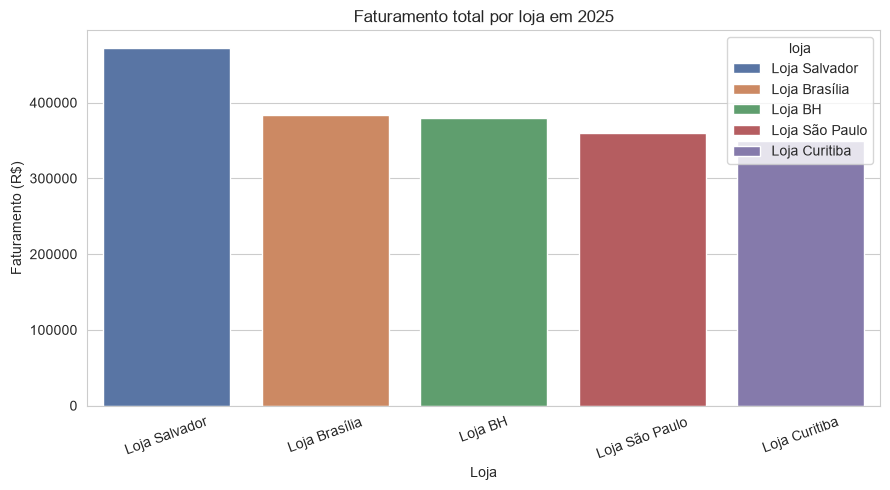

In [27]:
fig, ax = plt.subplots(figsize=(9, 5))
sns.barplot(data=fat_loja, x="loja", y="faturamento", hue="loja", palette="deep", legend=True, ax=ax)
ax.set_title("Faturamento total por loja em 2025")
ax.set_xlabel("Loja")
ax.set_ylabel("Faturamento (R$)")
plt.xticks(rotation=20)
plt.tight_layout()
plt.savefig("graficos/faturamento_por_loja.png", dpi=150)
plt.show()

 Gráfico de linhas: evolução mensal do faturamento

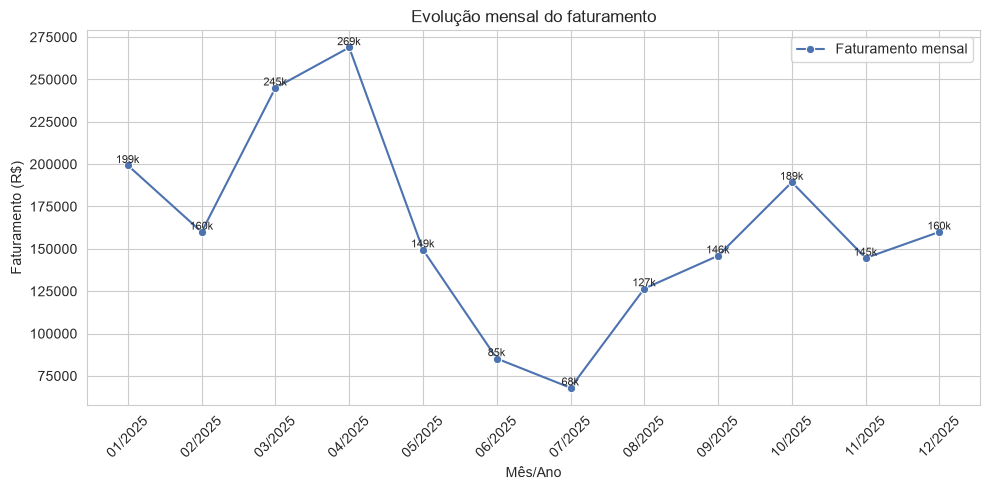

In [28]:
fig, ax = plt.subplots(figsize=(10, 5))
sns.lineplot(data=fat_mensal, x="periodo", y="faturamento", marker="o", label="Faturamento mensal", ax=ax)

for x, y in zip(fat_mensal["periodo"], fat_mensal["faturamento"]):
    ax.text(x, y, f"{y/1000:.0f}k", ha="center", va="bottom", fontsize=8)

ax.set_title("Evolução mensal do faturamento")
ax.set_xlabel("Mês/Ano")
ax.set_ylabel("Faturamento (R$)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("graficos/evolucao_mensal.png", dpi=150)
plt.show()

Gráfico de pizza: faturamento por região

In [29]:
fat_regiao = (
    vendas.groupby("regiao")["faturamento"]
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

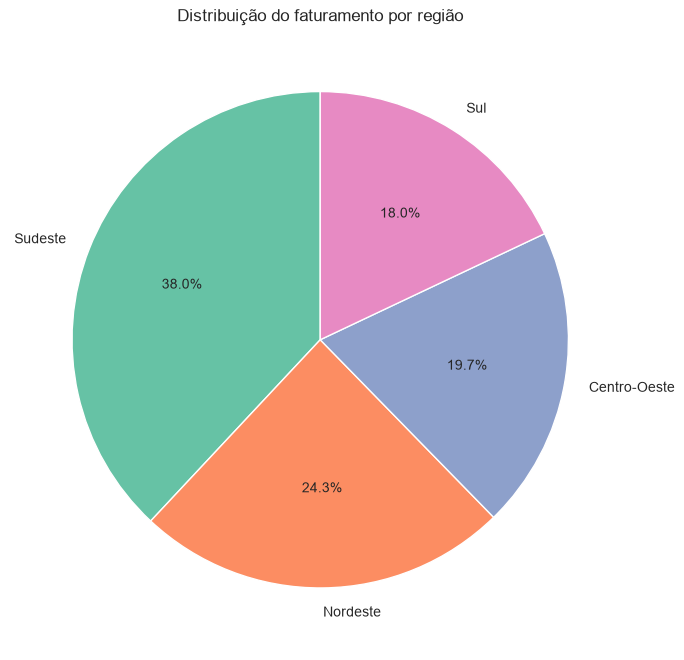

In [30]:
fig, ax = plt.subplots(figsize=(7, 7))
ax.pie(
    fat_regiao["faturamento"],
    labels=fat_regiao["regiao"],
    autopct="%1.1f%%",
    startangle=90,
    colors=sns.color_palette("Set2", len(fat_regiao)),
)
ax.set_title("Distribuição do faturamento por região")
plt.tight_layout()
plt.savefig("graficos/faturamento_por_regiao_pizza.png", dpi=150)
plt.show()

 Gráfico de dispersão: quantidade x faturamento

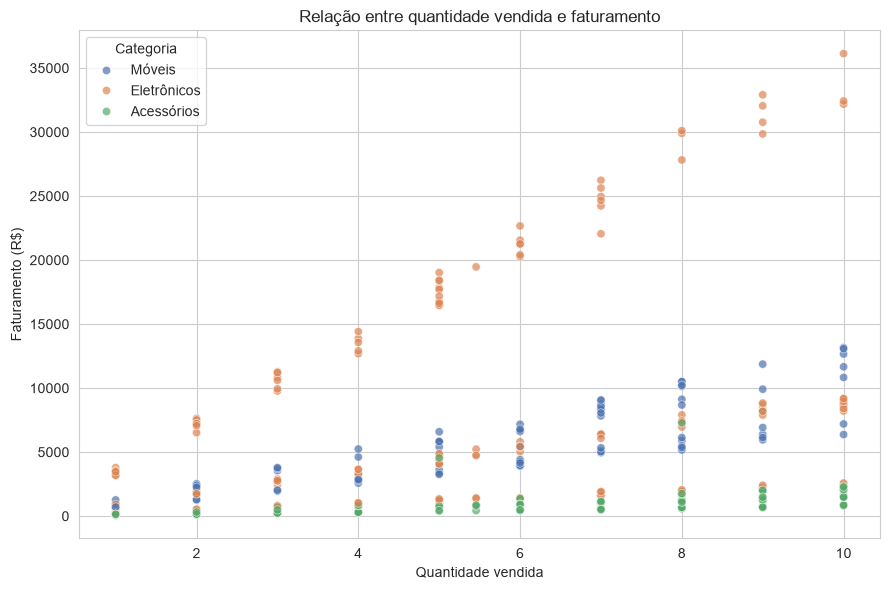

In [31]:
fig, ax = plt.subplots(figsize=(9, 6))
sns.scatterplot(data=vendas, x="quantidade", y="faturamento", hue="categoria", alpha=0.7, ax=ax)
ax.set_title("Relação entre quantidade vendida e faturamento")
ax.set_xlabel("Quantidade vendida")
ax.set_ylabel("Faturamento (R$)")
ax.legend(title="Categoria")
plt.tight_layout()
plt.savefig("graficos/dispersao_quantidade_faturamento.png", dpi=150)
plt.show()


Boxplot: preço unitário por categoria

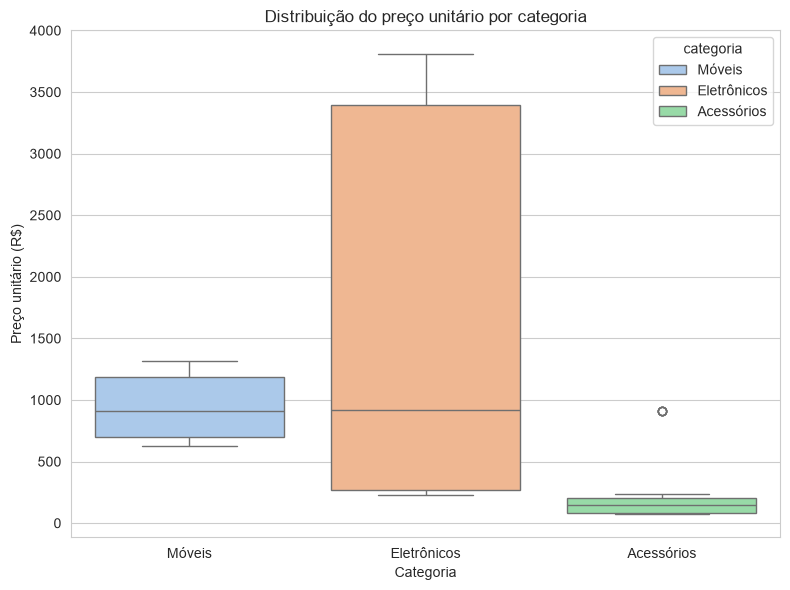

In [32]:
fig, ax = plt.subplots(figsize=(8, 6))
sns.boxplot(data=vendas, x="categoria", y="preco_unitario", hue="categoria", palette="pastel", legend=True, ax=ax)
ax.set_title("Distribuição do preço unitário por categoria")
ax.set_xlabel("Categoria")
ax.set_ylabel("Preço unitário (R$)")
plt.tight_layout()
plt.savefig("graficos/boxplot_preco_categoria.png", dpi=150)
plt.show()

 Heatmap: correlação entre as variáveis numéricas

In [33]:
corr = vendas[["quantidade", "preco_unitario", "faturamento", "mes"]].corr()

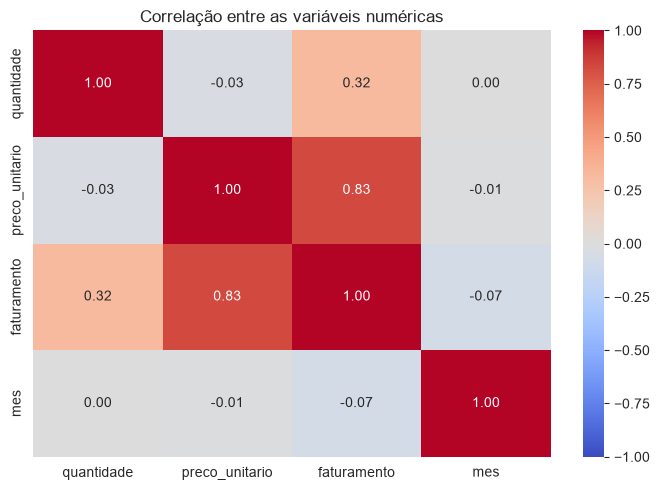

In [34]:
fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1, ax=ax)
ax.set_title("Correlação entre as variáveis numéricas")
plt.tight_layout()
plt.savefig("graficos/heatmap_correlacao.png", dpi=150)
plt.show()

## Etapa 4 - Estilização e Apresentação


Tema global


In [35]:
sns.set_style("whitegrid")
sns.set_palette(sns.color_palette("deep"))


 Layout com gráficos lado a lado

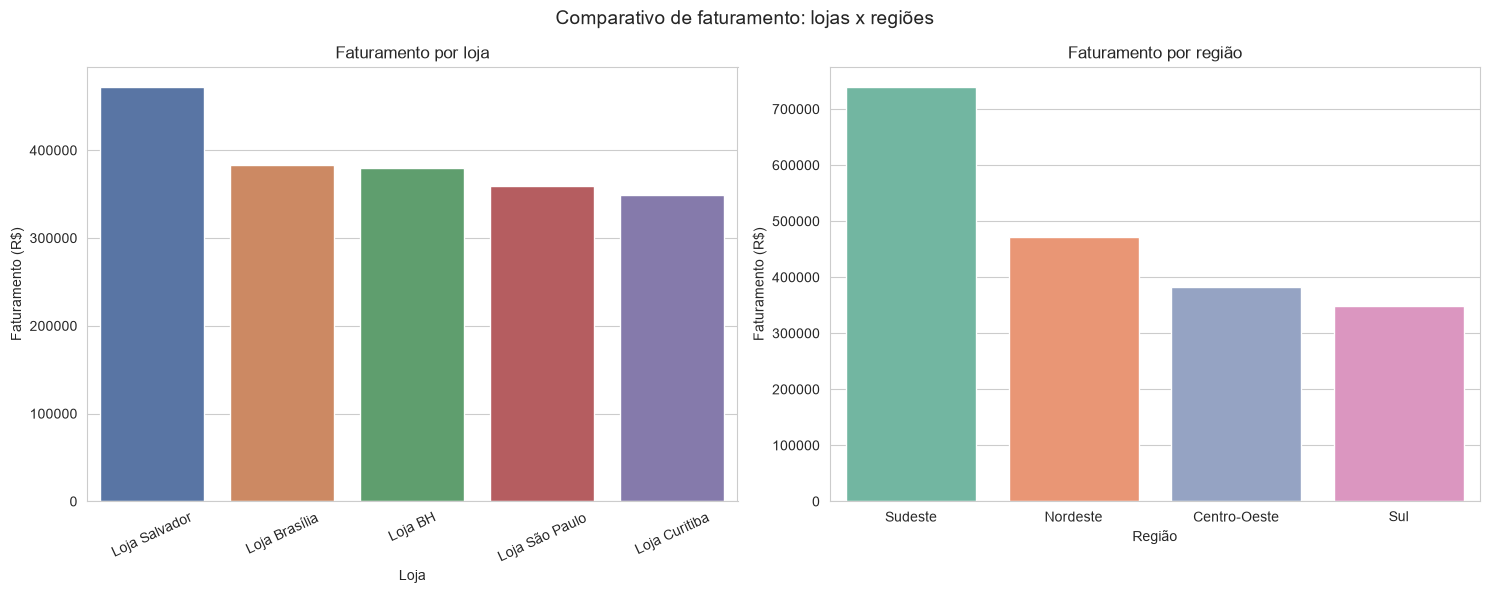

In [36]:
fig, axs = plt.subplots(1, 2, figsize=(15, 6))

sns.barplot(data=fat_loja, x="loja", y="faturamento", hue="loja", palette="deep", legend=False, ax=axs[0])
axs[0].set_title("Faturamento por loja")
axs[0].set_xlabel("Loja")
axs[0].set_ylabel("Faturamento (R$)")
axs[0].tick_params(axis="x", rotation=25)

sns.barplot(data=fat_regiao, x="regiao", y="faturamento", hue="regiao", palette="Set2", legend=False, ax=axs[1])
axs[1].set_title("Faturamento por região")
axs[1].set_xlabel("Região")
axs[1].set_ylabel("Faturamento (R$)")

fig.suptitle("Comparativo de faturamento: lojas x regiões", fontsize=14)
plt.tight_layout()
plt.savefig("graficos/comparativo_loja_regiao.png", dpi=150)
plt.show()

20 - Exportação e relatório final



In [37]:
resumo = pd.concat([
    fat_loja.rename(columns={"loja": "item", "faturamento": "valor"}).assign(indicador="Faturamento total por loja (R$)"),
    ticket_medio[["loja", "ticket_medio"]].rename(columns={"loja": "item", "ticket_medio": "valor"}).assign(indicador="Ticket médio por loja (R$)"),
    top5.rename(columns={"produto": "item", "quantidade": "valor"}).assign(indicador="Top 5 produtos (quantidade)"),
    fat_regiao.rename(columns={"regiao": "item", "faturamento": "valor"}).assign(indicador="Faturamento total por região (R$)"),
    fat_mensal[["periodo", "faturamento"]].rename(columns={"periodo": "item", "faturamento": "valor"}).assign(indicador="Faturamento mensal (R$)"),
], ignore_index=True)

resumo = resumo[["indicador", "item", "valor"]]
resumo["valor"] = resumo["valor"].round(2)

In [38]:
resumo.to_csv("resumo_analitico.csv", sep=";", index=False)

In [39]:
resumo

,indicador,item,valor
0,Faturamento total por loja (R$),Loja Salvador,471614.14
1,Faturamento total por loja (R$),Loja Brasília,382962.86
2,Faturamento total por loja (R$),Loja BH,379321.74
3,Faturamento total por loja (R$),Loja São Paulo,359327.04
4,Faturamento total por loja (R$),Loja Curitiba,349040.18
5,Ticket médio por loja (R$),Loja Brasília,5470.90
6,Ticket médio por loja (R$),Loja Salvador,5071.12
7,Ticket médio por loja (R$),Loja São Paulo,4922.29
8,Ticket médio por loja (R$),Loja Curitiba,4592.63
9,Ticket médio por loja (R$),Loja BH,4310.47


In [40]:
os.listdir("graficos")

['boxplot_preco_categoria.png',
 'comparativo_loja_regiao.png',
 'dispersao_quantidade_faturamento.png',
 'evolucao_mensal.png',
 'faturamento_por_loja.png',
 'faturamento_por_regiao_pizza.png',
 'heatmap_correlacao.png']